In [1]:
import sys
sys.path.append("..")
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import json
from datetime import datetime
from datasets import load_from_disk
from torch.utils.data import DataLoader

In [2]:
# Загрузка модели, корневая папка проекта
from src.data import PROJECT_ROOT, load_model_and_tokenizer, RuleTakerDataset, estimate_max_length, create_minimal_pairs, compute_differential_stats, analyze_neuron_activations
from src.probing import run_probing_experiment, load_probing_results
from src.llm_upgrade import wrap_for_transformer_lens

In [3]:
sns.set_style("whitegrid")

In [4]:
CACHE_DIR = PROJECT_ROOT / "data/processed"
RESULTS_DIR = PROJECT_ROOT / "results/probing"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

# Эксперименты по зондированию на GPT-2 Large

## Эксперимент 7-2: GPT-2 Large (seq QLoRA) + depth-1

In [6]:
# Параметры эксперимента
VARIANT = "depth-1"
MODEL_SIZE = "gpt2-large"
BASE_MODEL_NAME = "gpt2-large"
ADAPTER_PATH = PROJECT_ROOT / "results/checkpoints/finetune/exp7-2/checkpoint-4000"
USE_SMALL = True
HOOK_NAME = "resid_post"
POOLING = "last"
BATCH_SIZE = 8

### Подготовка модели и данных

In [7]:
hooked_model, tokenizer = wrap_for_transformer_lens(
    base_model_name=BASE_MODEL_NAME,
    adapter_path=str(ADAPTER_PATH),
    device="cuda"
)
hooked_model.eval()

`torch_dtype` is deprecated! Use `dtype` instead!
c:\MyPythonProjects\mephi_diss\.venv\Lib\site-packages\peft\tuners\lora\layer.py:2285: UserWarning: fan_in_fan_out is set to False but the target module is `Conv1D`. Setting fan_in_fan_out to True.
  warnings.warn(


Loaded pretrained model gpt2-large into HookedTransformer


HookedTransformer(
  (embed): Embed()
  (hook_embed): HookPoint()
  (pos_embed): PosEmbed()
  (hook_pos_embed): HookPoint()
  (blocks): ModuleList(
    (0-35): 36 x TransformerBlock(
      (ln1): LayerNorm(
        (hook_scale): HookPoint()
        (hook_normalized): HookPoint()
      )
      (ln2): LayerNorm(
        (hook_scale): HookPoint()
        (hook_normalized): HookPoint()
      )
      (attn): Attention(
        (hook_k): HookPoint()
        (hook_q): HookPoint()
        (hook_v): HookPoint()
        (hook_z): HookPoint()
        (hook_attn_scores): HookPoint()
        (hook_pattern): HookPoint()
        (hook_result): HookPoint()
      )
      (mlp): MLP(
        (hook_pre): HookPoint()
        (hook_post): HookPoint()
      )
      (hook_attn_in): HookPoint()
      (hook_q_input): HookPoint()
      (hook_k_input): HookPoint()
      (hook_v_input): HookPoint()
      (hook_mlp_in): HookPoint()
      (hook_attn_out): HookPoint()
      (hook_mlp_out): HookPoint()
      (hook_re

In [8]:
# Загружаем усеченную версию датасета
cache_suffix = f"{VARIANT}_small" if USE_SMALL else VARIANT
cache_path = CACHE_DIR / f"ruletaker_{cache_suffix}"
dataset = load_from_disk(str(cache_path))

In [9]:
# если выборка до 5000 наблюдений
tmp_tokens = tokenizer(list(dataset["train"]["text"]), padding=False, truncation=False)
lengths = [len(ids) for ids in tmp_tokens['input_ids']]
max_full = max(lengths)
max_p95 = int(np.percentile(lengths, 95))
print(f"95-й перцентиль: {max_p95} токенов (при макс длине {max_full})")

95-й перцентиль: 194 токенов (при макс длине 255)


In [10]:
# max_p95 = estimate_max_length(list(dataset["train"]["text"]), tokenizer, percentile=95, sample_size=500)

In [11]:
MAX_LENGTH = max_p95

In [12]:
train_dataset = RuleTakerDataset(dataset["train"], tokenizer, max_length=MAX_LENGTH)
dev_dataset = RuleTakerDataset(dataset["dev"], tokenizer, max_length=MAX_LENGTH)

In [13]:
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
dev_loader   = DataLoader(dev_dataset, batch_size=BATCH_SIZE, shuffle=False)

### Метод probing classifiers

In [14]:
n_layers = hooked_model.cfg.n_layers
d_model = hooked_model.cfg.d_model

In [15]:
n_layers

36

In [16]:
torch.cuda.empty_cache()

In [17]:
# Кэшируем активации
results = run_probing_experiment(
    hooked_model, train_loader, dev_loader, n_layers,
    hook_name=HOOK_NAME, pooling=POOLING
)

Probing layers:  67%|██████▋   | 24/36 [42:30<21:32, 107.68s/it]c:\MyPythonProjects\mephi_diss\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
Probing layers:  69%|██████▉   | 25/36 [44:18<19:46, 107.86s/it]c:\MyPythonProjects\mephi_diss\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the c

In [18]:
# Извлечение данных для графиков
train_accs = results["train_accs"]
dev_accs = results["dev_accs"]
train_means = [s["mean_abs"] for s in results["train_stats"]]
dev_means = [s["mean_abs"] for s in results["dev_stats"]]
train_stds = [s["std_abs"] for s in results["train_stats"]]
dev_stds = [s["std_abs"] for s in results["dev_stats"]]
train_sparsity = [s["sparsity"] for s in results["train_stats"]]
dev_sparsity = [s["sparsity"] for s in results["dev_stats"]]

In [19]:
# Визуализация результатов
best_layer = int(np.argmax(dev_accs))
best_train_acc = float(train_accs[best_layer])
best_dev_acc = float(dev_accs[best_layer])
print(f"Лучший слой: {best_layer} (0-based), Dev Accuracy: {best_dev_acc:.4f}")

Лучший слой: 20 (0-based), Dev Accuracy: 0.5320


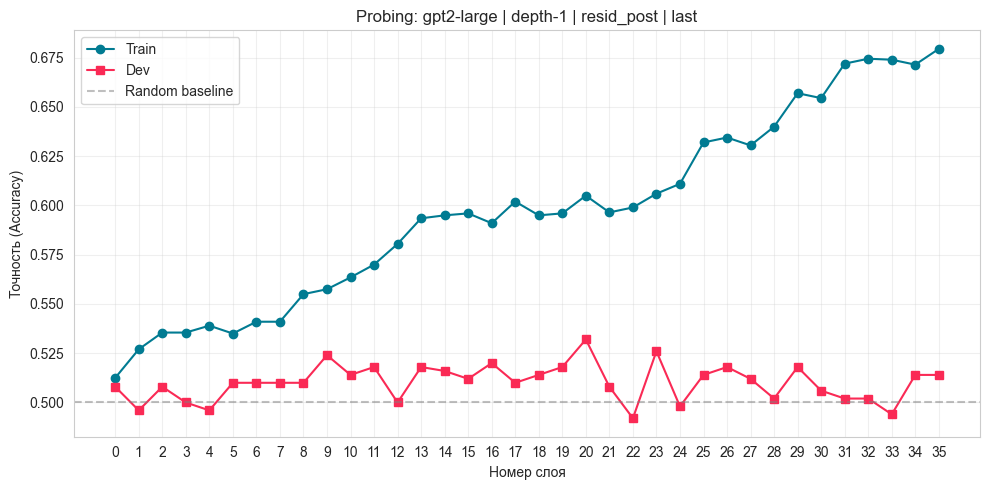

In [20]:
plt.figure(figsize=(10, 5))
x = np.arange(n_layers)
plt.plot(x, train_accs, marker="o", label="Train", color="xkcd:ocean")
plt.plot(x, dev_accs, marker="s", label="Dev", color="xkcd:red pink")
plt.axhline(0.5, color="gray", linestyle="--", alpha=0.5, label="Random baseline")
plt.xlabel("Номер слоя")
plt.ylabel("Точность (Accuracy)")
plt.title(f"Probing: {MODEL_SIZE} | {VARIANT} | {HOOK_NAME} | {POOLING}")
plt.xticks(x)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

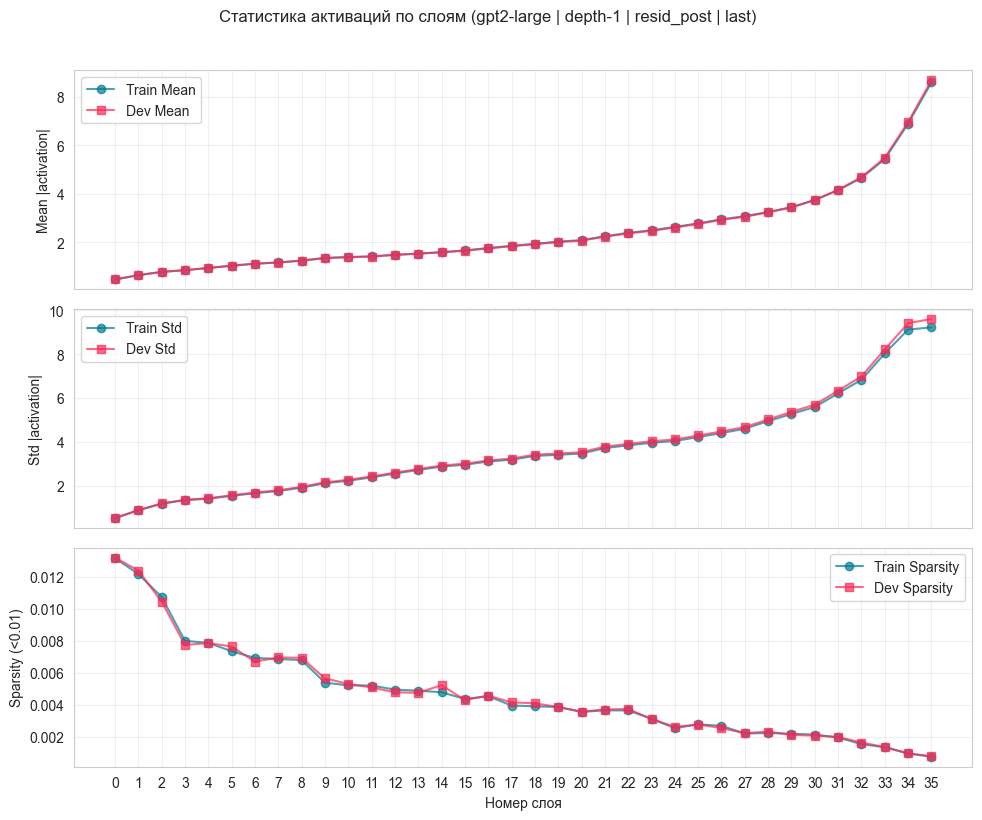

In [21]:
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(10, 8), sharex=True)

ax1.plot(x, train_means, marker="o", label="Train Mean", color="xkcd:ocean", alpha=0.7)
ax1.plot(x, dev_means, marker="s", label="Dev Mean", color="xkcd:red pink", alpha=0.7)
ax1.set_ylabel("Mean |activation|")
ax1.set_xticks(x)
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(x, train_stds, marker="o", label="Train Std", color="xkcd:ocean", alpha=0.7)
ax2.plot(x, dev_stds, marker="s", label="Dev Std", color="xkcd:red pink", alpha=0.7)
ax2.set_ylabel("Std |activation|")
ax2.legend()
ax2.grid(True, alpha=0.3)

ax3.plot(x, train_sparsity, marker="o", label="Train Sparsity", color="xkcd:ocean", alpha=0.7)
ax3.plot(x, dev_sparsity, marker="s", label="Dev Sparsity", color="xkcd:red pink", alpha=0.7)
ax3.set_ylabel("Sparsity (<0.01)")
ax3.set_xlabel("Номер слоя")
ax3.legend()
ax3.grid(True, alpha=0.3)

plt.suptitle(f"Статистика активаций по слоям ({MODEL_SIZE} | {VARIANT} | {HOOK_NAME} | {POOLING})", y=1.02)
plt.tight_layout()
plt.show()

In [22]:
# Сохранение метрик в JSON
fname = f"probe_{MODEL_SIZE}(seq_QLoRA)_{VARIANT}_{HOOK_NAME}_{POOLING}.json"
fpath = RESULTS_DIR / fname

In [23]:
metrics = {
    "variant": VARIANT,
    "model_size": MODEL_SIZE,
    "hook_name": HOOK_NAME,
    "pooling": POOLING,
    "best_layer": best_layer,
    "best_dev_acc": float(best_dev_acc),
    "train_accs": [float(a) for a in train_accs],
    "dev_accs": [float(a) for a in dev_accs]
}

# Исходные условия эксперимента
metadata = {
    "experiment_type": "probing_layer_selection",
    "timestamp": datetime.now().isoformat(),
    "variant": VARIANT,
    "model_size": MODEL_SIZE,
    "hook_name": HOOK_NAME,
    "pooling": POOLING,
    "batch_size": BATCH_SIZE,
    "max_length": MAX_LENGTH
}

# Основной результат
summary = {
    "best_layer": best_layer,
    "best_train_acc": best_train_acc,
    "best_dev_acc": best_dev_acc,
    "n_layers": len(results["layers"])
}

# Свод
full_data = {
    "metadata": metadata,
    "summary": summary,
    "layers": results["layers"],
    "train_accs": [float(x) for x in results["train_accs"]],
    "dev_accs": [float(x) for x in results["dev_accs"]],
    "train_stats": results["train_stats"],
    "dev_stats": results["dev_stats"]
}

with open(fpath, "w", encoding="utf-8") as f:
    json.dump(full_data, f, indent=2, ensure_ascii=False)
print(f"Результаты сохранены: {fpath}")

Результаты сохранены: C:\MyPythonProjects\mephi_diss\results\probing\probe_gpt2-large(seq_QLoRA)_depth-1_resid_post_last.json


### Проверка токенизации

In [24]:
# Список ключевых слов для проверки
logic_keywords = ["if", "then", "and", "or", "not", "implies", "is", "are", "all", "some", "no"]

In [25]:
# Возьмём несколько примеров из датасета (первые 3 из train)
sample_texts = list(dataset["train"]["text"])[:3]

In [26]:
for i, text in enumerate(sample_texts):
    print(f"Пример {i+1}:\n{text[:300]}...\n")  # первые 300 символов
    tokens = tokenizer.tokenize(text)
    print(f"Токены (первые 50): {tokens[:50]}\n")

    # Проверка каждого ключевого слова
    print("Наличие ключевых слов в тексте и токенах:")
    for kw in logic_keywords:
        in_text = kw in text.lower()
        # ищем токен, совпадающий с kw (без учёта регистра)
        in_tokens = any(tok.lstrip("Ġ").lower() == kw for tok in tokens)
        print(f"  '{kw}': в тексте={in_text}, в токенах={in_tokens}")
    print("-" * 80)

Пример 1:
Anne is quiet. Anne is not young. Bob is kind. Bob is young. Dave is rough. Dave is round. Dave is smart. Dave is not young. Fiona is quiet. Fiona is not round. Kind, young things are not smart. Bob is kind....

Токены (первые 50): ['Anne', 'Ġis', 'Ġquiet', '.', 'ĠAnne', 'Ġis', 'Ġnot', 'Ġyoung', '.', 'ĠBob', 'Ġis', 'Ġkind', '.', 'ĠBob', 'Ġis', 'Ġyoung', '.', 'ĠDave', 'Ġis', 'Ġrough', '.', 'ĠDave', 'Ġis', 'Ġround', '.', 'ĠDave', 'Ġis', 'Ġsmart', '.', 'ĠDave', 'Ġis', 'Ġnot', 'Ġyoung', '.', 'ĠFiona', 'Ġis', 'Ġquiet', '.', 'ĠFiona', 'Ġis', 'Ġnot', 'Ġround', '.', 'ĠKind', ',', 'Ġyoung', 'Ġthings', 'Ġare', 'Ġnot', 'Ġsmart']

Наличие ключевых слов в тексте и токенах:
  'if': в тексте=False, в токенах=False
  'then': в тексте=False, в токенах=False
  'and': в тексте=False, в токенах=False
  'or': в тексте=False, в токенах=False
  'not': в тексте=True, в токенах=True
  'implies': в тексте=False, в токенах=False
  'is': в тексте=True, в токенах=True
  'are': в тексте=True, в токенах=Tr

In [27]:
# Токенизация самих ключевых слов как отдельных строк
for kw in logic_keywords:
    tokens_kw = tokenizer.tokenize(kw)
    is_single = len(tokens_kw) == 1
    print(f"'{kw}' -> {tokens_kw} (цельный токен: {is_single})")

'if' -> ['if'] (цельный токен: True)
'then' -> ['then'] (цельный токен: True)
'and' -> ['and'] (цельный токен: True)
'or' -> ['or'] (цельный токен: True)
'not' -> ['not'] (цельный токен: True)
'implies' -> ['impl', 'ies'] (цельный токен: False)
'is' -> ['is'] (цельный токен: True)
'are' -> ['are'] (цельный токен: True)
'all' -> ['all'] (цельный токен: True)
'some' -> ['some'] (цельный токен: True)
'no' -> ['no'] (цельный токен: True)


### Разностный анализ активаций

In [28]:
data = load_probing_results(f"{MODEL_SIZE}(seq_qLoRA)", VARIANT, HOOK_NAME, POOLING)

In [29]:
data

{'metadata': {'experiment_type': 'probing_layer_selection',
  'timestamp': '2026-05-15T18:26:44.499002',
  'variant': 'depth-1',
  'model_size': 'gpt2-large',
  'hook_name': 'resid_post',
  'pooling': 'last',
  'batch_size': 8,
  'max_length': 194},
 'summary': {'best_layer': 20,
  'best_train_acc': 0.605,
  'best_dev_acc': 0.532,
  'n_layers': 36},
 'layers': [0,
  1,
  2,
  3,
  4,
  5,
  6,
  7,
  8,
  9,
  10,
  11,
  12,
  13,
  14,
  15,
  16,
  17,
  18,
  19,
  20,
  21,
  22,
  23,
  24,
  25,
  26,
  27,
  28,
  29,
  30,
  31,
  32,
  33,
  34,
  35],
 'train_accs': [0.5125,
  0.527,
  0.5355,
  0.5355,
  0.539,
  0.535,
  0.541,
  0.541,
  0.555,
  0.5575,
  0.5635,
  0.57,
  0.5805,
  0.5935,
  0.595,
  0.596,
  0.591,
  0.602,
  0.595,
  0.596,
  0.605,
  0.5965,
  0.599,
  0.606,
  0.611,
  0.632,
  0.6345,
  0.6305,
  0.64,
  0.657,
  0.6545,
  0.672,
  0.6745,
  0.674,
  0.6715,
  0.6795],
 'dev_accs': [0.508,
  0.496,
  0.508,
  0.5,
  0.496,
  0.51,
  0.51,
  0.51,
 

In [30]:
DIFF_LAYER = data["summary"]["best_layer"]

In [31]:
pairs = create_minimal_pairs(variant=VARIANT, n_pairs=30)

In [32]:
diff_stats = compute_differential_stats(
    hooked_model, tokenizer, pairs,
    layer_idx=DIFF_LAYER,
    hook_name=HOOK_NAME,
    pooling=POOLING,
    max_length=data["metadata"]["max_length"]   # или из MAX_LENGTH
)

In [33]:
print(f"Средняя абсолютная разница активаций: {diff_stats['mean_abs_diff']:.4f}")
print(f"Стандартное отклонение разницы: {diff_stats['std_diff']:.4f}")

Средняя абсолютная разница активаций: 0.0292
Стандартное отклонение разницы: 0.0518


In [35]:
neuron_sens = diff_stats['neuron_sensitivity']
top_neurons = np.argsort(neuron_sens)[-100:][::-1]
print("Топ-100 нейронов с наибольшей средней разницей:")
for i, n in enumerate(top_neurons):
    print(f"  Нейрон {n}: {neuron_sens[n]:.4f}")

Топ-100 нейронов с наибольшей средней разницей:
  Нейрон 440: 0.9333
  Нейрон 792: 0.5500
  Нейрон 8: 0.4292
  Нейрон 89: 0.1833
  Нейрон 1061: 0.1542
  Нейрон 22: 0.1354
  Нейрон 248: 0.1208
  Нейрон 768: 0.1207
  Нейрон 183: 0.1063
  Нейрон 24: 0.0938
  Нейрон 939: 0.0906
  Нейрон 429: 0.0906
  Нейрон 215: 0.0896
  Нейрон 197: 0.0849
  Нейрон 433: 0.0844
  Нейрон 1087: 0.0815
  Нейрон 870: 0.0792
  Нейрон 750: 0.0781
  Нейрон 490: 0.0750
  Нейрон 251: 0.0729
  Нейрон 953: 0.0714
  Нейрон 91: 0.0698
  Нейрон 940: 0.0677
  Нейрон 71: 0.0661
  Нейрон 964: 0.0648
  Нейрон 287: 0.0646
  Нейрон 448: 0.0630
  Нейрон 521: 0.0629
  Нейрон 54: 0.0625
  Нейрон 131: 0.0625
  Нейрон 555: 0.0620
  Нейрон 1208: 0.0611
  Нейрон 790: 0.0604
  Нейрон 468: 0.0594
  Нейрон 1014: 0.0594
  Нейрон 1268: 0.0586
  Нейрон 1095: 0.0584
  Нейрон 247: 0.0583
  Нейрон 1252: 0.0578
  Нейрон 886: 0.0576
  Нейрон 705: 0.0573
  Нейрон 742: 0.0559
  Нейрон 963: 0.0557
  Нейрон 223: 0.0557
  Нейрон 482: 0.0555
  Нейрон

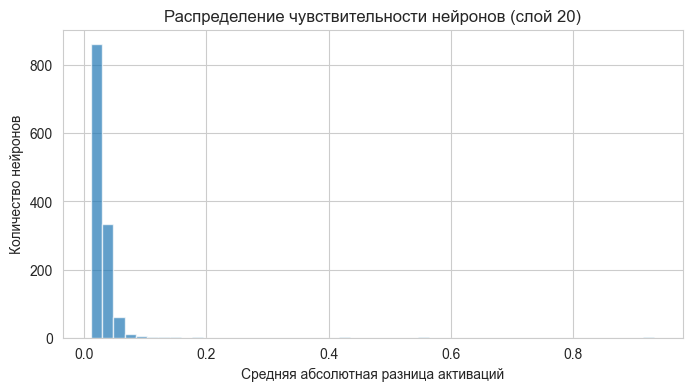

In [36]:
# Гистограмма чувствительности нейронов
plt.figure(figsize=(8,4))
plt.hist(neuron_sens, bins=50, alpha=0.7)
plt.xlabel("Средняя абсолютная разница активаций")
plt.ylabel("Количество нейронов")
plt.title(f"Распределение чувствительности нейронов (слой {DIFF_LAYER})")
plt.grid(True)
plt.show()

In [37]:
# Добавляем результаты разностного анализа в файл json с результатами пробинга
diff_stats["neuron_sensitivity"] = diff_stats["neuron_sensitivity"].tolist()
data["diff_stats"] = diff_stats
with open(fpath, "w", encoding="utf-8") as f:
    json.dump(data, f, indent=2, ensure_ascii=False)
    print(f"Результаты разностного анализа добавлены в {fpath}")

Результаты разностного анализа добавлены в C:\MyPythonProjects\mephi_diss\results\probing\probe_gpt2-large(seq_QLoRA)_depth-1_resid_post_last.json


In [38]:
top_texts, top_tokens = analyze_neuron_activations(
    hooked_model, tokenizer,
    layer_idx=20, neuron_idx=440,
    texts=list(dataset["train"]["text"])[:200],
    top_k_examples=10,
    top_k_tokens=30
)

In [39]:
print("Топ-10 примеров для нейрона 440:")
for text, act in top_texts:
    print(f"  [{act:.3f}] {text}")

Топ-10 примеров для нейрона 440:
  [44.250] The bald eagle chases the cow. The bald eagle eats the bear. The bald eagle is not rough. The bear chases the bald eagle. The bear eats the cow. The bear is nice. The bear does not visit the cow. The cow does not eat the bald eagle. The cow is green. The cow is rough. The cow visits the bald eagle. The cow visits the bear. If someone chases the cow then they do not visit the bear. The bald eagle visits the bald eagle.
  [42.500] The cow is rough. The cow is round. The cow likes the tiger. The tiger chases the cow. The tiger is big. The tiger is blue. The tiger likes the cow. If the cow likes the tiger and the tiger chases the cow then the cow chases the tiger. The cow chases the cow.
  [41.000] The bear eats the mouse. The bear is blue. The bear is cold. The bear is green. The bear is not kind. The bear is rough. The bear does not need the mouse. The bear visits the mouse. The mouse eats the bear. The mouse is blue. The mouse is cold. The mou

In [40]:
print("Топ-30 токенов для нейрона 440:")
for token, score in top_tokens:
    print(f"{token.strip()}: {score:+.3f}")

Топ-30 токенов для нейрона 440:
iona: +99.500
Smart: +88.500
quiet: +76.237
Rough: +76.091
furry: +71.928
rough: +71.520
Fiona: +70.991
cold: +70.393
smart: +70.039
Anne: +69.889
Charlie: +69.220
blue: +68.865
cat: +68.653
green: +68.562
round: +67.797
red: +67.751
ases: +67.539
nice: +66.841
young: +65.616
sees: +64.932
Erin: +64.764
visits: +63.757
white: +63.337
bear: +63.301
F: +62.833
Bob: +62.762
big: +62.382
dog: +61.645
cow: +61.622
tiger: +61.397
